In [ ]:
from sklearn.datasets import fetch_openml

# Load MNIST (70,000 samples, 784 features)
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target

print("Shape of X:", X.shape)   # (70000, 784)
print("Shape of y:", y.shape)   # (70000,)


Shape of X: (70000, 784)
Shape of y: (70000,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape after scaling:", X_scaled.shape)


Shape after scaling: (70000, 784)


In [ ]:
import numpy as np

# Covariance matrix
cov_matrix = np.cov(X_scaled.T)

# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)


Eigenvalues shape: (784,)
Eigenvectors shape: (784, 784)


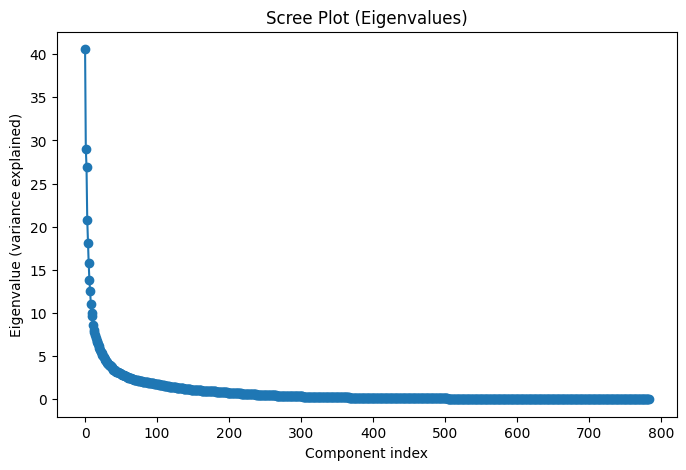

In [ ]:
import matplotlib.pyplot as plt

# Sort eigenvalues in descending order
sorted_eigenvalues = np.sort(eigenvalues)[::-1]

# Scree plot: variance explained by each component
plt.figure(figsize=(8,5))
plt.plot(sorted_eigenvalues, marker='o')
plt.title("Scree Plot (Eigenvalues)")
plt.xlabel("Component index")
plt.ylabel("Eigenvalue (variance explained)")
plt.show()


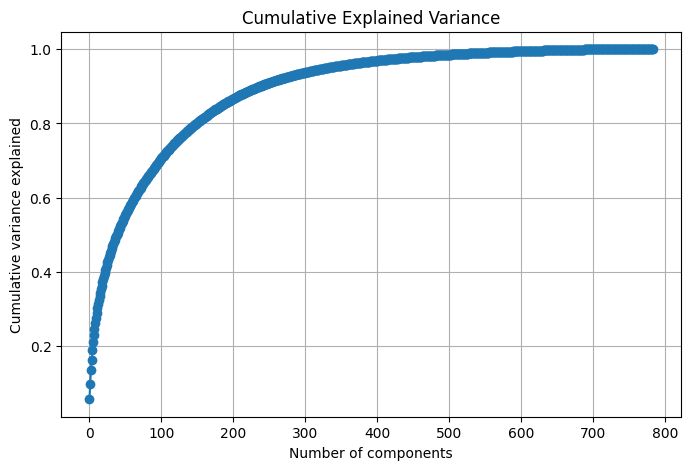

In [ ]:
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance_ratio), marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance explained")
plt.grid(True)
plt.show()


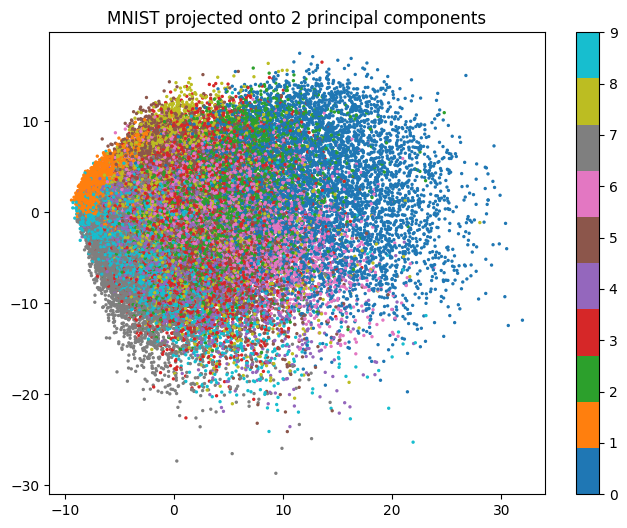

In [ ]:
# Select top 2 eigenvectors (principal components)
top2_eigenvectors = eigenvectors[:, :2]

# Project data
X_pca_2d = X_scaled.dot(top2_eigenvectors)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y.astype(int), cmap='tab10', s=2)
plt.colorbar()
plt.title("MNIST projected onto 2 principal components")
plt.show()


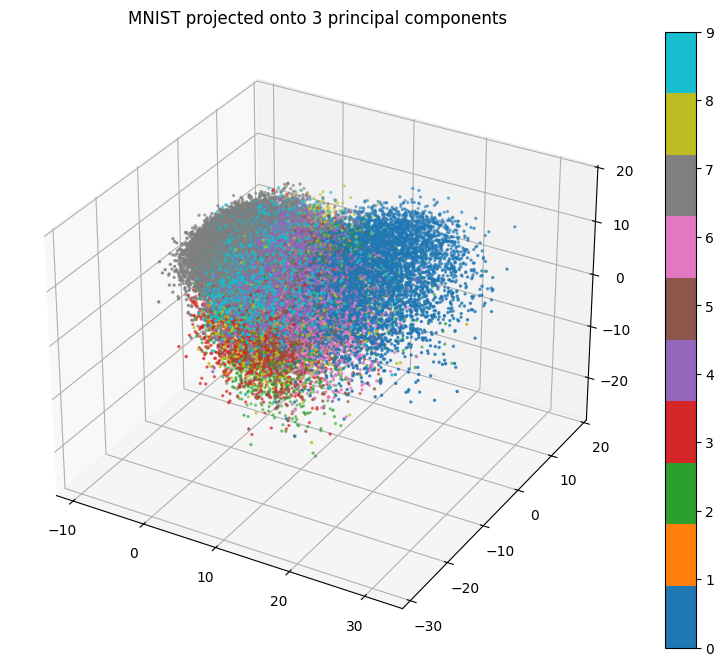

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

top3_eigenvectors = eigenvectors[:, :3]
X_pca_3d = X_scaled.dot(top3_eigenvectors)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2],
                     c=y.astype(int), cmap='tab10', s=2)
plt.colorbar(scatter)
plt.title("MNIST projected onto 3 principal components")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y.astype(int), test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train on full dataset
clf_full = LogisticRegression(max_iter=1000)
clf_full.fit(X_train, y_train)

y_pred_full = clf_full.predict(X_test)
print("Accuracy (full dataset):", accuracy_score(y_test, y_pred_full))


Accuracy (full dataset): 0.9156428571428571


In [ ]:
from sklearn.decomposition import PCA

# Reduce to 50 components
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train on reduced dataset
clf_pca = LogisticRegression(max_iter=1000)
clf_pca.fit(X_train_pca, y_train)

y_pred_pca = clf_pca.predict(X_test_pca)
print("Accuracy (PCA-reduced dataset):", accuracy_score(y_test, y_pred_pca))


Accuracy (PCA-reduced dataset): 0.9065


In [ ]:
import time

# Full dataset timing
start = time.time()
clf_full.fit(X_train, y_train)
end = time.time()
print("Training time (full dataset):", end - start, "seconds")

# PCA dataset timing
start = time.time()
clf_pca.fit(X_train_pca, y_train)
end = time.time()
print("Training time (PCA dataset):", end - start, "seconds")


Training time (full dataset): 93.92547535896301 seconds
Training time (PCA dataset): 15.635151386260986 seconds
